# Klasifikasi Karya Seni Manusia & AI

## Import Library

In [1]:
# Library yang sering digunakan
import os, shutil
import zipfile
import random
from random import sample
import shutil
from shutil import copyfile
import pathlib
from pathlib import Path
import numpy as np
import pandas as pd
from tqdm.notebook import tqdm as tq
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
from PIL import Image
import datetime

In [2]:
# Libraries untuk pemrosesan data gambar
import cv2
from PIL import Image
import skimage
from skimage import io
from skimage.transform import resize
from skimage.transform import rotate, AffineTransform, warp
from skimage import img_as_ubyte
from skimage.exposure import adjust_gamma
from skimage.util import random_noise

In [4]:
# Libraries untuk pembangunan model
import keras
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import tensorflow as tf
from tensorflow.keras import Model, layers
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array, load_img
from tensorflow.keras.optimizers import Adam, RMSprop, SGD
from tensorflow.keras.layers import InputLayer, Conv2D, SeparableConv2D, MaxPooling2D, MaxPool2D, Dense, Flatten, Dropout, BatchNormalization, GlobalAveragePooling2D, Input
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.applications import MobileNet
from tensorflow.keras.applications.densenet import DenseNet121
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import ModelCheckpoint, Callback, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.applications import ResNet50, EfficientNetB0
!pip install tensorflowjs
import tensorflowjs as tfjs
from sklearn.utils import class_weight

## Data Loading

In [5]:
import os
import json

# 1. Konfigurasi Kredensial
os.environ['KAGGLE_USERNAME'] = "dhlihh"
os.environ['KAGGLE_KEY'] = "KGAT_3a177c4de4e3900b1f6e6bc50946aa53"

# 2. Membuat folder .kaggle dan file kaggle.json
!mkdir -p ~/.kaggle
token = {"username": os.environ['KAGGLE_USERNAME'], "key": os.environ['KAGGLE_KEY']}
with open(os.path.expanduser('~/.kaggle/kaggle.json'), 'w') as file:
    json.dump(token, file)

# 3. Memberikan izin akses agar aman
!chmod 600 ~/.kaggle/kaggle.json

print("Konfigurasi selesai! Memulai download dataset...")

# 4. Download dataset (menggunakan slug dataset yang kamu minta)
!kaggle datasets download -d kausthubkannan/ai-and-human-art-classification

# 5. Ekstrak dataset
# File yang didownload biasanya bernama 'ai-and-human-art-classification.zip'
!unzip -q ai-and-human-art-classification.zip

print("Selesai! Dataset kamu ada di folder 'dataset_art'")

Konfigurasi selesai! Memulai download dataset...
Dataset URL: https://www.kaggle.com/datasets/kausthubkannan/ai-and-human-art-classification
License(s): DbCL-1.0
100% 2.21G/2.21G [00:32<00:00, 73.1MB/s]

Selesai! Dataset kamu ada di folder 'dataset_art'


## Data Preparation

In [6]:
# Direktori awal untuk train dan test
train_dir = "ai_art_classification/train"
test_dir = "ai_art_classification/test"

# Direktori baru untuk dataset gabungan
combined_dir = "ai_art_classification/dataset"

In [7]:
# Buat direktori baru untuk dataset gabungan
os.makedirs(combined_dir, exist_ok=True)

In [8]:
# Salin file dan folder dari train
for category in os.listdir(train_dir):
  # ai generated dan non ai generated
    category_dir = os.path.join(train_dir, category)
    print(category_dir)
    if os.path.isdir(category_dir):
        shutil.copytree(category_dir, os.path.join(combined_dir, category), dirs_exist_ok=True)

# Salin file dan folder dari test
for category in os.listdir(test_dir):
  # ai generated dan non ai generated
    category_dir = os.path.join(test_dir, category)
    if os.path.isdir(category_dir):
        shutil.copytree(category_dir, os.path.join(combined_dir, category), dirs_exist_ok=True)

ai_art_classification/train/AI_GENERATED
ai_art_classification/train/NON_AI_GENERATED


## Dataset Checking

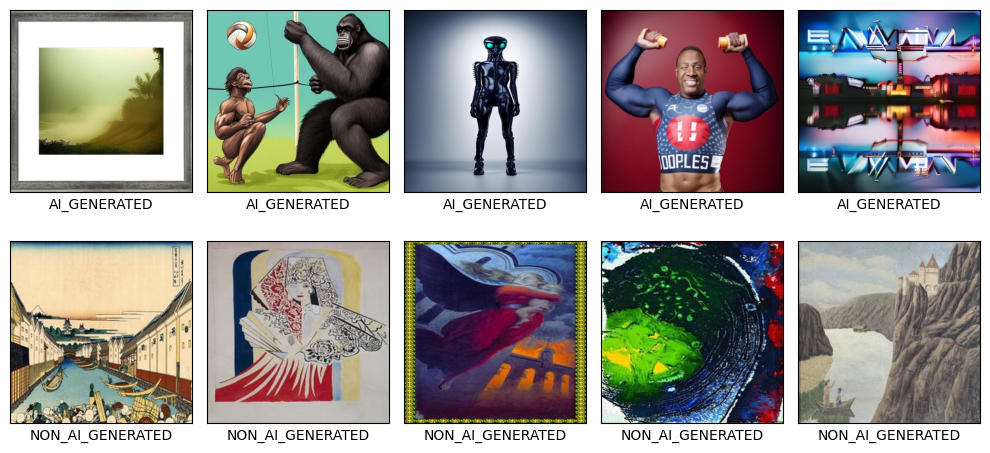

In [9]:
# Membuat kamus yang menyimpan gambar untuk setiap kelas dalam data
art_image = {}

# Tentukan path sumber train
path = "ai_art_classification/"
path_sub = os.path.join(path, "dataset")

# i : ai generated dan non ai generated
for i in os.listdir(path_sub):
    art_image[i] = os.listdir(os.path.join(path_sub, i))

# Menampilkan secara acak 5 gambar di bawah setiap dari 2 kelas dari data.
# Anda akan melihat gambar yang berbeda setiap kali kode ini dijalankan.
path_sub = "ai_art_classification/dataset/"

# Menampilkan secara acak 5 gambar di bawah setiap kelas dari data latih
fig, axs = plt.subplots(len(art_image.keys()), 5, figsize=(10, 5))

for i, class_name in enumerate(os.listdir(path_sub)):
    images = np.random.choice(art_image[class_name], 5, replace=False)

    for j, image_name in enumerate(images):
        img_path = os.path.join(path_sub, class_name, image_name)
        img = Image.open(img_path)
        axs[i, j].imshow(img)
        axs[i, j].set(xlabel=class_name, xticks=[], yticks=[])

fig.tight_layout()

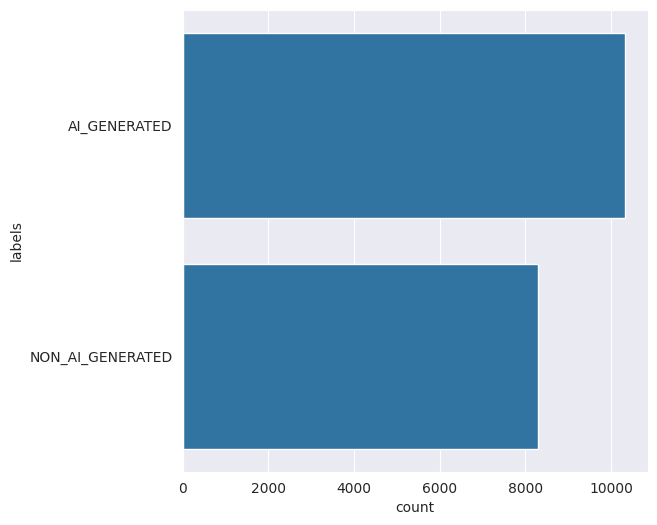

In [10]:
from tensorflow.python.ops.gen_logging_ops import Print
# Definisikan path sumber
art_path = "ai_art_classification/dataset/"

# Buat daftar yang menyimpan data untuk setiap nama file, path file, dan label dalam data
file_name = []
labels = []
full_path = []

# Dapatkan nama file gambar, path file, dan label satu per satu dengan looping, dan simpan sebagai dataframe
for path, subdirs, files in os.walk(art_path):
    for name in files:
        full_path.append(os.path.join(path, name))
        labels.append(path.split('/')[-1])
        file_name.append(name)

distribution_train = pd.DataFrame({"path":full_path, 'file_name':file_name, "labels":labels})

# Plot distribusi gambar di setiap kelas
Label = distribution_train['labels']
plt.figure(figsize = (6,6))
sns.set_style("darkgrid")
plot_data = sns.countplot(Label)

## Data Splitting

In [11]:
# Panggil variabel mypath yang menampung folder dataset gambar
mypath= 'ai_art_classification/dataset/'

file_name = []
labels = []
full_path = []
for path, subdirs, files in os.walk(mypath):
    for name in files:
        full_path.append(os.path.join(path, name))
        labels.append(path.split('/')[-1])
        file_name.append(name)

# Memasukkan variabel yang sudah dikumpulkan pada looping di atas menjadi sebuah dataframe agar rapi
df = pd.DataFrame({"path":full_path,'file_name':file_name,"labels":labels})
# Melihat jumlah data gambar pada masing-masing label
df.groupby(['labels']).size()

,0
labels,
AI_GENERATED,10330
NON_AI_GENERATED,8288


In [12]:
df.head()

,path,file_name,labels
0,ai_art_classification/dataset/AI_GENERATED/305...,3054.jpg,AI_GENERATED
1,ai_art_classification/dataset/AI_GENERATED/201...,2018.jpg,AI_GENERATED
2,ai_art_classification/dataset/AI_GENERATED/116...,11679.jpg,AI_GENERATED
3,ai_art_classification/dataset/AI_GENERATED/151...,15198.jpg,AI_GENERATED
4,ai_art_classification/dataset/AI_GENERATED/474...,4745.jpg,AI_GENERATED


In [13]:
X= df['path']
y= df['labels']

from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.2, random_state=300, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=300, stratify=y_temp
)

print(f"Jumlah Data Train      : {len(X_train)}")
print(f"Jumlah Data Validation : {len(X_val)}")
print(f"Jumlah Data Test       : {len(X_test)}")

Jumlah Data Train      : 14894
Jumlah Data Validation : 1862
Jumlah Data Test       : 1862


In [14]:
# Menyatukan ke dalam masing-masing dataframe
df_tr = pd.DataFrame({'path':X_train,'labels':y_train,'set':'train'})
df_va = pd.DataFrame({'path':X_val,'labels':y_val,'set':'val'})
df_te = pd.DataFrame({'path':X_test,'labels':y_test,'set':'test'})

In [15]:
df_tr

,path,labels,set
1881,ai_art_classification/dataset/AI_GENERATED/608...,AI_GENERATED,train
2038,ai_art_classification/dataset/AI_GENERATED/532...,AI_GENERATED,train
3540,ai_art_classification/dataset/AI_GENERATED/164...,AI_GENERATED,train
13880,ai_art_classification/dataset/NON_AI_GENERATED...,NON_AI_GENERATED,train
14505,ai_art_classification/dataset/NON_AI_GENERATED...,NON_AI_GENERATED,train
...,...,...,...
11845,ai_art_classification/dataset/NON_AI_GENERATED...,NON_AI_GENERATED,train
16857,ai_art_classification/dataset/NON_AI_GENERATED...,NON_AI_GENERATED,train
12675,ai_art_classification/dataset/NON_AI_GENERATED...,NON_AI_GENERATED,train
16448,ai_art_classification/dataset/NON_AI_GENERATED...,NON_AI_GENERATED,train


In [17]:
df_va

,path,labels,set
12138,ai_art_classification/dataset/NON_AI_GENERATED...,NON_AI_GENERATED,val
44,ai_art_classification/dataset/AI_GENERATED/423...,AI_GENERATED,val
13568,ai_art_classification/dataset/NON_AI_GENERATED...,NON_AI_GENERATED,val
6567,ai_art_classification/dataset/AI_GENERATED/106...,AI_GENERATED,val
16663,ai_art_classification/dataset/NON_AI_GENERATED...,NON_AI_GENERATED,val
...,...,...,...
9232,ai_art_classification/dataset/AI_GENERATED/129...,AI_GENERATED,val
8901,ai_art_classification/dataset/AI_GENERATED/512...,AI_GENERATED,val
3841,ai_art_classification/dataset/AI_GENERATED/162...,AI_GENERATED,val
15504,ai_art_classification/dataset/NON_AI_GENERATED...,NON_AI_GENERATED,val


In [16]:
df_te

,path,labels,set
17465,ai_art_classification/dataset/NON_AI_GENERATED...,NON_AI_GENERATED,test
7065,ai_art_classification/dataset/AI_GENERATED/122...,AI_GENERATED,test
17601,ai_art_classification/dataset/NON_AI_GENERATED...,NON_AI_GENERATED,test
17288,ai_art_classification/dataset/NON_AI_GENERATED...,NON_AI_GENERATED,test
6439,ai_art_classification/dataset/AI_GENERATED/586...,AI_GENERATED,test
...,...,...,...
14366,ai_art_classification/dataset/NON_AI_GENERATED...,NON_AI_GENERATED,test
1926,ai_art_classification/dataset/AI_GENERATED/117...,AI_GENERATED,test
9456,ai_art_classification/dataset/AI_GENERATED/934...,AI_GENERATED,test
1205,ai_art_classification/dataset/AI_GENERATED/602...,AI_GENERATED,test


In [18]:
# Gabungkan DataFrame df_tr dan df_te
df_all = pd.concat([df_tr, df_te, df_va], ignore_index=True)

print('===================================================== \n')
print(df_all.groupby(['set', 'labels']).size(), '\n')
print('===================================================== \n')

# Cek sampel data
print(df_all.sample(5))

# Memanggil dataset asli yang berisi keseluruhan data gambar yang sesuai dengan labelnya
datasource_path = "ai_art_classification/dataset/"
# Membuat variabel Dataset, tempat menampung data yang telah dilakukan pembagian data training dan testing
dataset_path = "Dataset-Final/"


set    labels          
test   AI_GENERATED        1033
       NON_AI_GENERATED     829
train  AI_GENERATED        8264
       NON_AI_GENERATED    6630
val    AI_GENERATED        1033
       NON_AI_GENERATED     829
dtype: int64 


                                                    path        labels    set
15370  ai_art_classification/dataset/AI_GENERATED/531...  AI_GENERATED   test
13873  ai_art_classification/dataset/AI_GENERATED/134...  AI_GENERATED  train
5118   ai_art_classification/dataset/AI_GENERATED/164...  AI_GENERATED  train
3389   ai_art_classification/dataset/AI_GENERATED/829...  AI_GENERATED  train
15303  ai_art_classification/dataset/AI_GENERATED/873...  AI_GENERATED   test


In [19]:
for index, row in tq(df_all.iterrows()):
    # Deteksi filepath
    file_path = row['path']

    if os.path.exists(file_path) == False:
            print("yes")
            # datasource_path = "ai_art_classification/dataset/"
            file_path = os.path.join(datasource_path,row['labels'],row['image'].split('.')[0])

    # Buat direktori tujuan folder (dataset_path = "Dataset-Final/")
    if os.path.exists(os.path.join(dataset_path,row['set'],row['labels'])) == False:
        os.makedirs(os.path.join(dataset_path,row['set'],row['labels']))

    # Tentukan tujuan file
    destination_file_name = file_path.split('/')[-1]
    file_dest = os.path.join(dataset_path,row['set'],row['labels'],destination_file_name)

    # Salin file dari sumber ke tujuan
    if os.path.exists(file_dest) == False:
        shutil.copy2(file_path,file_dest)

0it [00:00, ?it/s]

## Image Data Generator

In [20]:
# Definisikan direktori training dan test
TRAIN_DIR = "Dataset-Final/train/"
TEST_DIR = "Dataset-Final/test/"
VAL_DIR = "Dataset-Final/val/"

train_non_ai = os.path.join(TRAIN_DIR + '/NON_AI_GENERATED')
train_ai = os.path.join(TRAIN_DIR + '/AI_GENERATED')

val_non_ai = os.path.join(TEST_DIR + '/NON_AI_GENERATED')
val_ai = os.path.join(TEST_DIR + '/AI_GENERATED')

test_non_ai = os.path.join(TEST_DIR + '/NON_AI_GENERATED')
test_ai = os.path.join(TEST_DIR + '/AI_GENERATED')

print("Total number of normal images in training set: ",len(os.listdir(train_non_ai )))
print("Total number of pneumonic images in training set: ",len(os.listdir(train_ai)))

print("Total number of normal images in validation set: ",len(os.listdir(val_non_ai)))
print("Total number of pneumonic images in validation set: ",len(os.listdir(val_ai)))

print("Total number of normal images in test set: ",len(os.listdir(test_non_ai)))
print("Total number of pneumonic images in test set: ",len(os.listdir(test_ai)))

Total number of normal images in training set:  6630
Total number of pneumonic images in training set:  8264
Total number of normal images in validation set:  829
Total number of pneumonic images in validation set:  1033
Total number of normal images in test set:  829
Total number of pneumonic images in test set:  1033


In [21]:
from tensorflow.keras.applications.resnet50 import preprocess_input

# Buat objek ImageDataGenerator yang menormalkan gambar
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=10,
    zoom_range=0.1,
    brightness_range=[0.8, 1.2],
    horizontal_flip=True,
    fill_mode='nearest',
    width_shift_range=0.15,
    height_shift_range=0.15,
    shear_range=0.1
)
datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_generator = train_datagen.flow_from_directory(TRAIN_DIR,
                                              batch_size=16,
                                              target_size=(416,416),
                                              class_mode='binary',
                                              shuffle=True)

validation_generator = datagen.flow_from_directory(VAL_DIR,
                                                   batch_size=16,
                                                   target_size=(416,416),
                                                   class_mode='binary',
                                                   shuffle=False)

test_generator = datagen.flow_from_directory(TEST_DIR,
                                                  batch_size=16,
                                                  target_size=(416,416),
                                                  class_mode='binary',
                                                  shuffle=False)

Found 14894 images belonging to 2 classes.
Found 1862 images belonging to 2 classes.
Found 1862 images belonging to 2 classes.


## Pelatihan Model

In [22]:
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(416, 416, 3))
base_model.trainable = False # Membekukan weight asli ResNet

# Membangun model Sequential
model = Sequential([
    base_model, # ResNet50 yang sudah di-freeze

    Conv2D(512, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    GlobalAveragePooling2D(),

    # Fully Connected Layer
    Dense(512, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

model.compile(tf.keras.optimizers.Adam(learning_rate=0.0001), loss='binary_crossentropy', metrics=['accuracy'], )

model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 13, 13, 2048)   │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 13, 13, 512)    │     9,437,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 13, 13, 512)    │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 6, 6, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,290,625 (126.99 MB)

 Trainable params: 9,701,889 (37.01 MB)

 Non-trainable params: 23,588,736 (89.98 MB)

In [23]:
# Early Stopping: Berhenti jika val_loss tidak turun dalam 5 epoch
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

# Learning rate scheduler
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2, min_lr=1e-7)

callbacks_list = [early_stop, reduce_lr]

In [31]:
weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)

class_weights_dict = dict(enumerate(weights))

history = model.fit(
    train_generator,
    epochs=30,
    validation_data=validation_generator,
    callbacks=callbacks_list,
    class_weight=class_weights_dict,
    verbose=1
)

Epoch 1/30
931/931 ━━━━━━━━━━━━━━━━━━━━ 785s 822ms/step - accuracy: 0.9102 - loss: 0.2152 - val_accuracy: 0.9329 - val_loss: 0.1745 - learning_rate: 1.0000e-04
Epoch 2/30
931/931 ━━━━━━━━━━━━━━━━━━━━ 730s 784ms/step - accuracy: 0.9443 - loss: 0.1392 - val_accuracy: 0.9538 - val_loss: 0.1152 - learning_rate: 1.0000e-04
Epoch 3/30
931/931 ━━━━━━━━━━━━━━━━━━━━ 742s 797ms/step - accuracy: 0.9609 - loss: 0.1037 - val_accuracy: 0.9458 - val_loss: 0.1268 - learning_rate: 1.0000e-04
Epoch 4/30
931/931 ━━━━━━━━━━━━━━━━━━━━ 806s 801ms/step - accuracy: 0.9686 - loss: 0.0818 - val_accuracy: 0.9463 - val_loss: 0.1214 - learning_rate: 1.0000e-04
Epoch 5/30
931/931 ━━━━━━━━━━━━━━━━━━━━ 740s 795ms/step - accuracy: 0.9832 - loss: 0.0501 - val_accuracy: 0.9629 - val_loss: 0.1026 - learning_rate: 2.0000e-05
Epoch 6/30
931/931 ━━━━━━━━━━━━━━━━━━━━ 754s 810ms/step - accuracy: 0.9887 - loss: 0.0389 - val_accuracy: 0.9597 - val_loss: 0.1088 - learning_rate: 2.0000e-05
Epoch 7/30
931/931 ━━━━━━━━━━━━━━━━━━━━ 

## Evaluasi Model

In [33]:
# Evaluasi model pada data testing
test_loss, test_acc = model.evaluate(test_generator, verbose=1)

print(f'\nLoss pada Data Testing: {test_loss:.4f}')
print(f'Akurasi pada Data Testing: {test_acc * 100:.2f}%')

117/117 ━━━━━━━━━━━━━━━━━━━━ 36s 211ms/step - accuracy: 0.9544 - loss: 0.1278

Loss pada Data Testing: 0.1278
Akurasi pada Data Testing: 95.44%


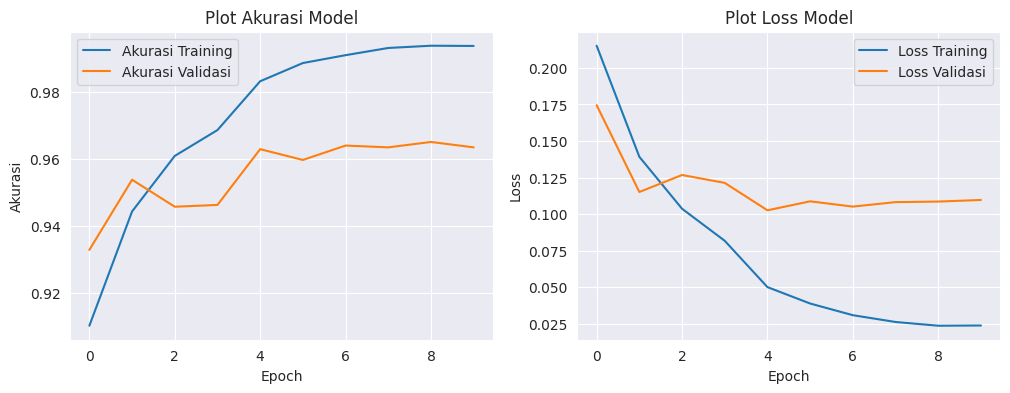

In [34]:
akurasi = history.history['accuracy']
akurasi_val = history.history['val_accuracy']
loss = history.history['loss']
loss_val = history.history['val_loss']

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(akurasi, label='Akurasi Training')
plt.plot(akurasi_val, label='Akurasi Validasi')
plt.title('Plot Akurasi Model')
plt.xlabel('Epoch')
plt.ylabel('Akurasi')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(loss, label='Loss Training')
plt.plot(loss_val, label='Loss Validasi')
plt.title('Plot Loss Model')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

117/117 ━━━━━━━━━━━━━━━━━━━━ 24s 206ms/step


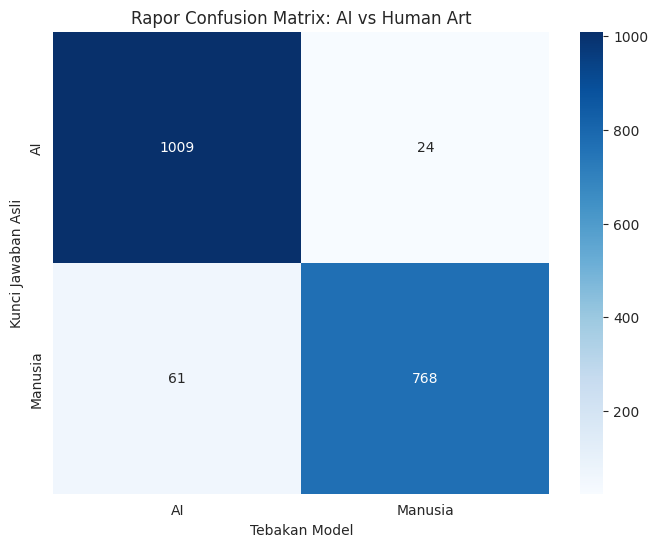

In [37]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. Mengambil prediksi dari model menggunakan data validasi/testing
tebakan_desimal = model.predict(test_generator)

# 2. Mengubah nilai probabilitas menjadi kelas 0 atau 1
# Jika tebakan di atas 50% (0.5), anggap kelas 1 (AI). Jika di bawah, kelas 0 (Manusia)
tebakan_kelas = (tebakan_desimal > 0.5).astype(int)

# 3. Mengambil kunci jawaban asli dari generator data Anda
kunci_jawaban_asli = test_generator.classes

# 4. Membuat Confusion Matrix
cm = confusion_matrix(kunci_jawaban_asli, tebakan_kelas)

# 5. Menggambar matriksnya agar cantik dan mudah dibaca
plt.figure(figsize=(8, 6)) # Mengatur ukuran kanvas gambar

# sns.heatmap berfungsi membuat kotak warna-warni.
# annot=True untuk memunculkan angkanya. fmt='d' agar angkanya bulat (bukan desimal).
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['AI', 'Manusia'],
            yticklabels=['AI', 'Manusia'])

# Memberi label pada sumbu X dan Y
plt.xlabel('Tebakan Model')
plt.ylabel('Kunci Jawaban Asli')
plt.title('Rapor Confusion Matrix: AI vs Human Art')

# Menyimpan atau menampilkan gambar
plt.show()

## Konversi Model

In [43]:
# 1. Membuat struktur folder utama 'submission' dan sub-foldernya
os.makedirs('submission/saved_model', exist_ok=True)
os.makedirs('submission/tflite', exist_ok=True)
os.makedirs('submission/tfjs_model', exist_ok=True)

# 2. Menyimpan format SavedModel (.pb dan variables)
model.export('submission/saved_model')

# 3. Konversi dan menyimpan format TFLite
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

with open('submission/tflite/model.tflite', 'wb') as f:
    f.write(tflite_model)

label_dict = train_generator.class_indices

label_names = list(label_dict.keys())

with open('submission/tflite/label.txt', 'w') as f:
    f.write('\n'.join(label_names))

# 5. Konversi dan menyimpan format TensorFlow.js
tfjs.converters.save_keras_model(model, 'submission/tfjs_model')

Saved artifact at 'submission/saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 416, 416, 3), dtype=tf.float32, name='keras_tensor_175')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  133329740128976: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133329740130128: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133329740129168: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133329740130320: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133329740128208: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133329740130512: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133329740131664: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133329740133008: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133329740134928: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133329740135120: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1333

failed to lookup keras version from the file,
    this is likely a weight only file


In [47]:
# 1. Perintah untuk membungkus folder menjadi file .zip
!zip -r submission.zip submission/

# 2. Mengimpor alat khusus dari Google Colab
from google.colab import files

# 3. Memicu browser untuk mengunduh file .zip tersebut
files.download('submission.zip')

  adding: submission/ (stored 0%)
  adding: submission/saved_model/ (stored 0%)
  adding: submission/saved_model/saved_model.pb (deflated 91%)
  adding: submission/saved_model/variables/ (stored 0%)
  adding: submission/saved_model/variables/variables.index (deflated 80%)
  adding: submission/saved_model/variables/variables.data-00000-of-00001 (deflated 7%)
  adding: submission/saved_model/fingerprint.pb (stored 0%)
  adding: submission/saved_model/assets/ (stored 0%)
  adding: submission/tfjs_model/ (stored 0%)
  adding: submission/tfjs_model/group1-shard17of32.bin (deflated 7%)
  adding: submission/tfjs_model/group1-shard29of32.bin (deflated 7%)
  adding: submission/tfjs_model/group1-shard6of32.bin (deflated 8%)
  adding: submission/tfjs_model/group1-shard23of32.bin (deflated 7%)
  adding: submission/tfjs_model/group1-shard18of32.bin (deflated 7%)
  adding: submission/tfjs_model/group1-shard20of32.bin (deflated 7%)
  adding: submission/tfjs_model/group1-shard24of32.bin (deflated 7%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Inferensi

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


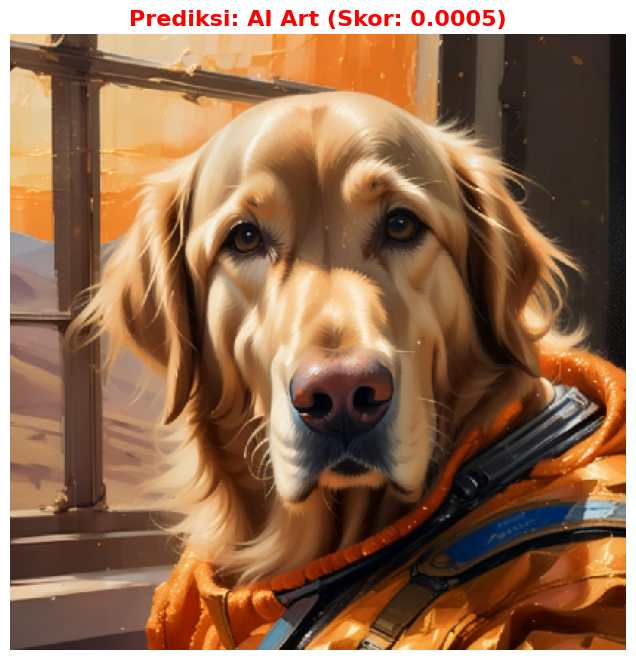

In [73]:
# 1. Muat model TFLite dari dalam folder submission
interpreter = tf.lite.Interpreter(model_path="submission/tflite/model.tflite")
interpreter.allocate_tensors()

# 2. Ambil informasi tentang "pintu masuk" (input) dan "pintu keluar" (output) model
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

# 3. Mengunduh gambar dari internet (URL)
url_gambar = 'https://www.img2go.com/assets/dist/images/oil_painting.06bd3e3c.jpg'

# Fungsi get_file akan mendownload gambar dan menyimpannya sementara dengan nama 'gambar_test.jpg'
img_path = tf.keras.utils.get_file('gambar_test.jpg', origin=url_gambar)

# 4. Memuat gambar yang sudah didownload ke memori dengan ukuran 416x416
img = image.load_img(img_path, target_size=(416, 416))

# 5. Preprocessing (Mempersiapkan gambar agar bahasa formatnya dimengerti oleh ResNet50)
x = image.img_to_array(img)        # Mengubah gambar visual menjadi angka-angka (array)
x = np.expand_dims(x, axis=0)      # Menambah dimensi batch (dari 416,416,3 menjadi 1,416,416,3)
x = preprocess_input(x)            # Normalisasi piksel khusus gaya ResNet50

# 6. Memasukkan data gambar ke dalam model
interpreter.set_tensor(input_details[0]['index'], x)

# Menjalankan mesin prediksi (Inferensi)
interpreter.invoke()

# Mengambil hasil tebakan dari model
hasil_prediksi = interpreter.get_tensor(output_details[0]['index'])
skor = hasil_prediksi[0][0]

if skor > 0.5:
    label_prediksi = "Human Art"
    warna_judul = 'green' # Hijau untuk Manusia
else:
    label_prediksi = "AI Art"
    warna_judul = 'red' # Merah untuk AI

# 8. Proses Menampilkan Gambar (Plotting)
plt.figure(figsize=(8, 8))
plt.imshow(img) # Menampilkan gambar asli yang belum diubah ke array angka
plt.title(f"Prediksi: {label_prediksi} (Skor: {skor:.4f})",
          fontsize=16, color=warna_judul, fontweight='bold')
plt.axis('off') # Mematikan garis sumbu x dan y
plt.show()

## Export Requirements

In [69]:
# Install alat pipreqsnb
!pip install pipreqsnb

!pipreqsnb notebook.ipynb --savepath submission/requirements.txt

pipreqs  --savepath submission/requirements.txt /content/__temp_pipreqsnb_folder
INFO: Not scanning for jupyter notebooks.
Please, verify manually the final list of requirements.txt to avoid possible dependency confusions.
Please, verify manually the final list of requirements.txt to avoid possible dependency confusions.
Please, verify manually the final list of requirements.txt to avoid possible dependency confusions.
Please, verify manually the final list of requirements.txt to avoid possible dependency confusions.
Please, verify manually the final list of requirements.txt to avoid possible dependency confusions.
Please, verify manually the final list of requirements.txt to avoid possible dependency confusions.
Please, verify manually the final list of requirements.txt to avoid possible dependency confusions.
Please, verify manually the final list of requirements.txt to avoid possible dependency confusions.
Please, verify manually the final list of requirements.txt to avoid possible 